In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.shape

(48895, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
print("Neighbourhood Groups:")
print(df["neighbourhood_group"].unique())

print("\nRoom Types:")
print(df["room_type"].unique())

Neighbourhood Groups:
<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

Room Types:
<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str


In [11]:
target = "price"

In [12]:
print("Minimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())
print("Average Price:", df["price"].mean())
print("Median Price:", df["price"].median())

Minimum Price: 0
Maximum Price: 10000
Average Price: 152.7206871868289
Median Price: 106.0


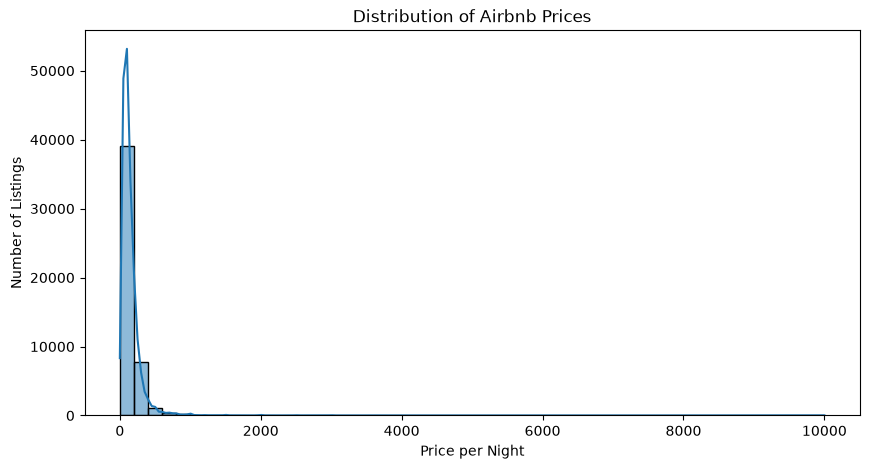

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")

plt.show()

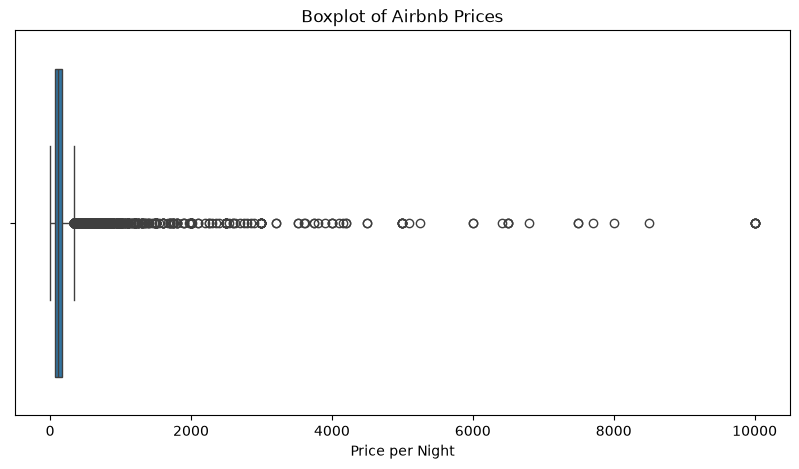

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price per Night")

plt.show()

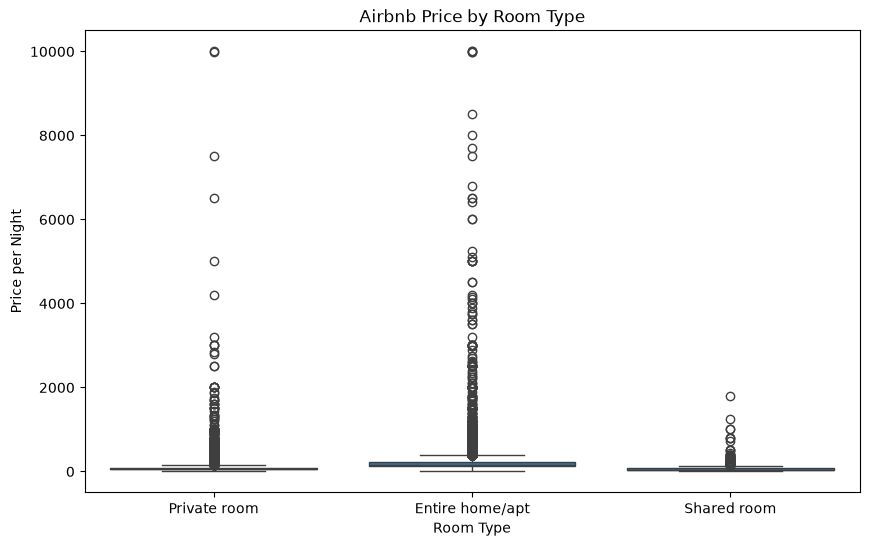

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night")

plt.show()

In [16]:
room_price = df.groupby("room_type")["price"].mean()

print(room_price)

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64


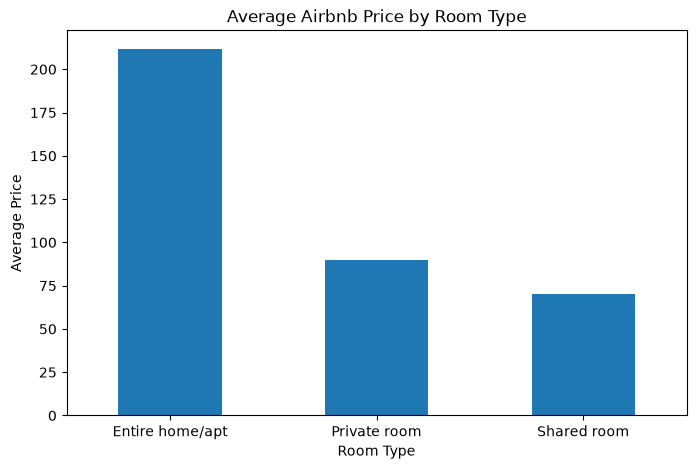

In [19]:
plt.figure(figsize=(8, 5))

room_price.plot(kind="bar")

plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.show()

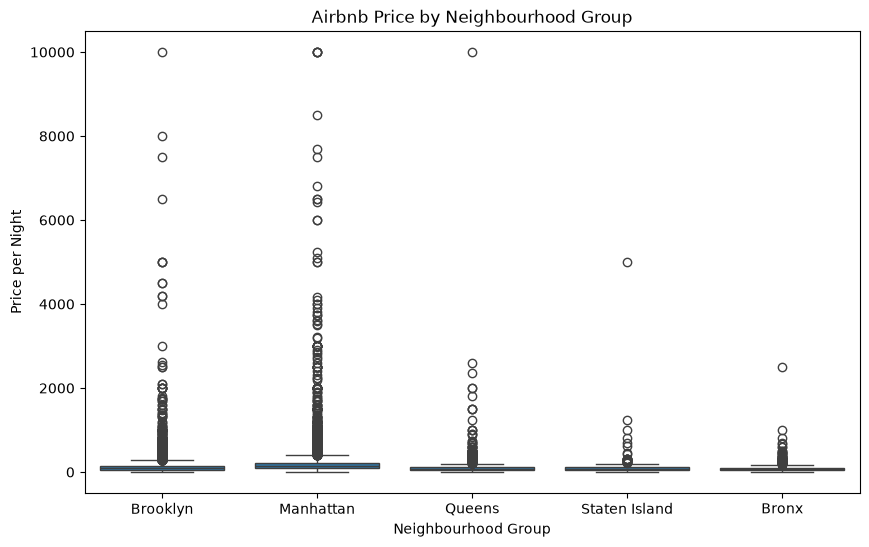

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.title("Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price per Night")

plt.show()

In [21]:
neighbourhood_price = df.groupby(
    "neighbourhood_group"
)["price"].mean()

print(neighbourhood_price)

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64


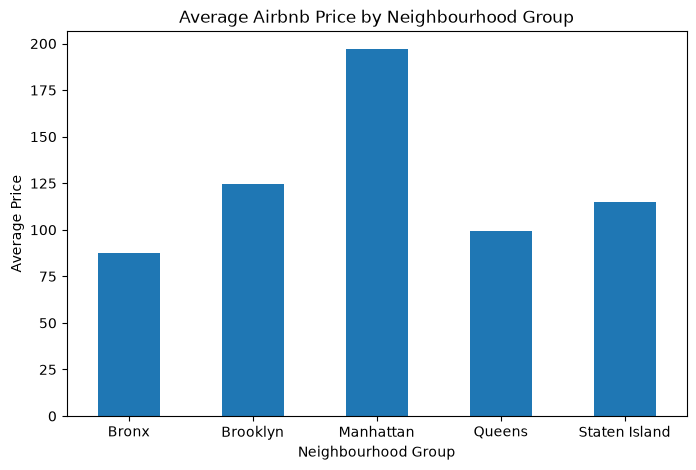

In [24]:
plt.figure(figsize=(8, 5))

neighbourhood_price.plot(kind="bar")

plt.title("Average Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.show()

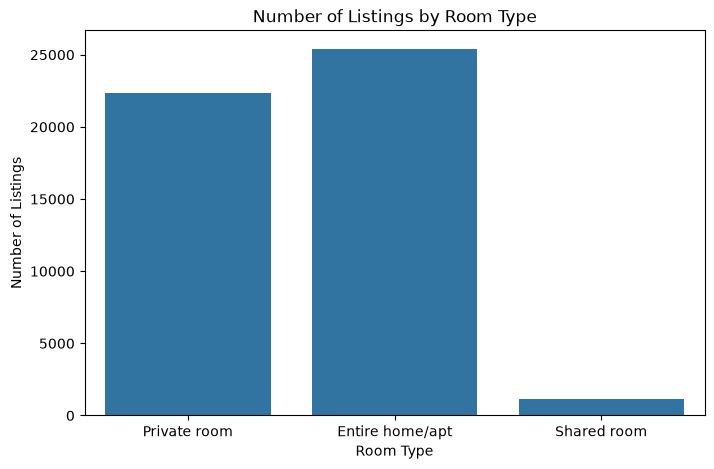

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=0)

plt.show()

In [26]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()["price"].sort_values(
    ascending=False
)

print(correlation)

price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
host_id                           0.015309
id                                0.010619
reviews_per_month                -0.030608
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64


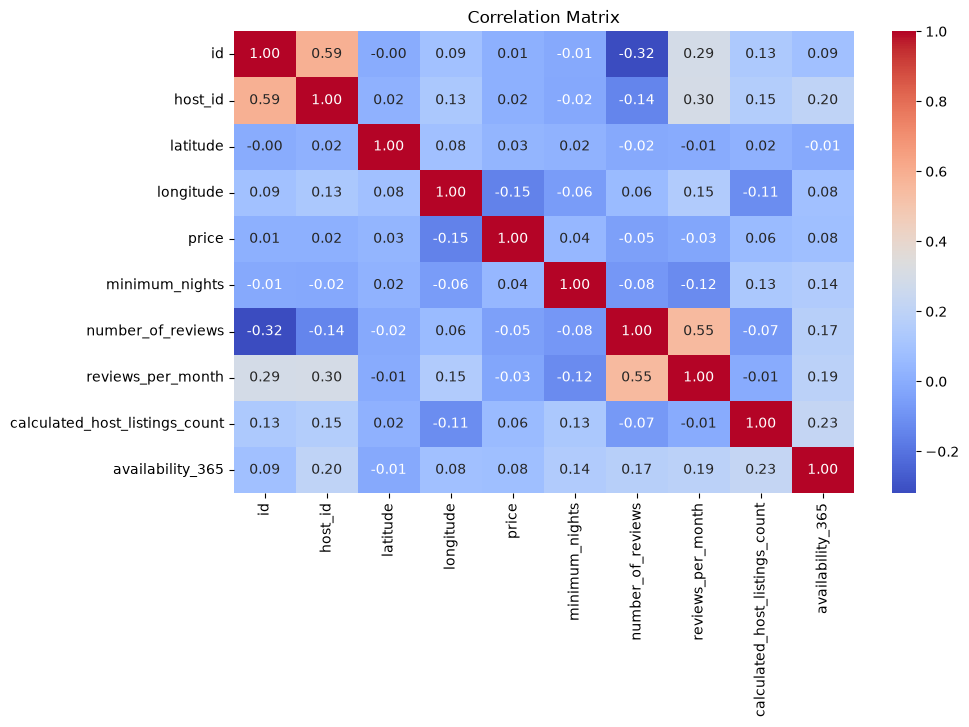

In [28]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

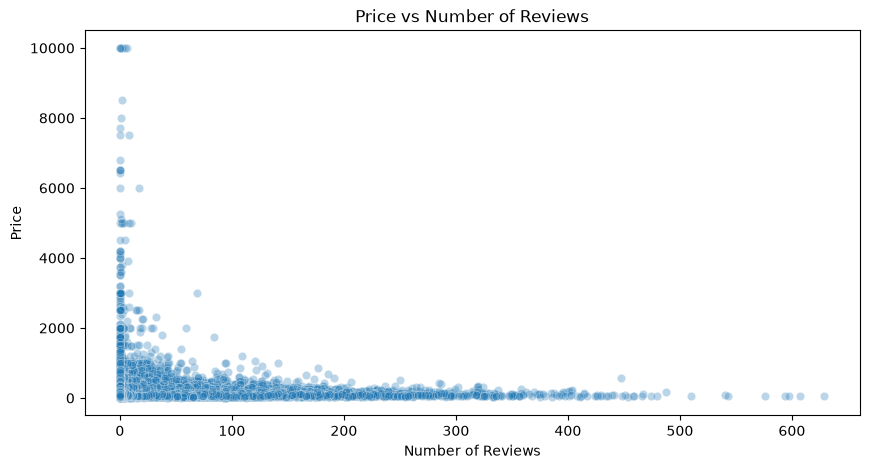

In [31]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="price",
    alpha=0.3
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()

In [32]:
clean_df = df.copy()

print("Original shape:", df.shape)
print("Working shape:", clean_df.shape)

Original shape: (48895, 16)
Working shape: (48895, 16)


In [33]:
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 0


In [34]:
clean_df = clean_df.drop_duplicates()

print("Shape after removing duplicates:", clean_df.shape)

Shape after removing duplicates: (48895, 16)


In [35]:
print("Price = 0:", (clean_df["price"] == 0).sum())
print("Price < 0:", (clean_df["price"] < 0).sum())

Price = 0: 11
Price < 0: 0


In [36]:
clean_df = clean_df[clean_df["price"] > 0]

print("Shape after removing invalid prices:", clean_df.shape)

Shape after removing invalid prices: (48884, 16)


In [37]:
clean_df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                 10051
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [38]:
print(clean_df.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [39]:
clean_df = clean_df.drop(
    columns=[
        "id",
        "host_id",
        "name",
        "host_name",
        "last_review"
    ]
)

In [41]:
clean_df["last_review"] = df.loc[clean_df.index, "last_review"]

In [42]:
clean_df["last_review"] = pd.to_datetime(
    clean_df["last_review"],
    errors="coerce"
)

In [43]:
clean_df["has_review"] = clean_df["last_review"].notna().astype(int)

reference_date = clean_df["last_review"].max()

clean_df["days_since_last_review"] = (
    reference_date - clean_df["last_review"]
).dt.days

In [44]:
clean_df[
    ["last_review", "has_review", "days_since_last_review"]
].head(10)

,last_review,has_review,days_since_last_review
0,2018-10-19,1,262.0
1,2019-05-21,1,48.0
2,NaT,0,NaN
3,2019-07-05,1,3.0
4,2018-11-19,1,231.0
5,2019-06-22,1,16.0
6,2017-10-05,1,641.0
7,2019-06-24,1,14.0
8,2017-07-21,1,717.0
9,2019-06-09,1,29.0


In [46]:
clean_df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'last_review', 'has_review',
       'days_since_last_review'],
      dtype='str')

In [47]:
clean_df["reviews_per_month"] = clean_df["reviews_per_month"].fillna(0)

In [48]:
clean_df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
last_review                       10051
has_review                            0
days_since_last_review            10051
dtype: int64

In [50]:
clean_df = clean_df.drop(columns=["last_review"])

In [51]:
clean_df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_review,days_since_last_review
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,262.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,48.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0,NaN
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,3.0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,231.0


In [52]:
clean_df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_review                            0
days_since_last_review            10051
dtype: int64

In [53]:
Q1 = clean_df["price"].quantile(0.25)
Q3 = clean_df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Limit: -90.0
Upper Limit: 334.0


In [54]:
outliers = clean_df[clean_df["price"] > upper_limit]

print("Number of price outliers:", len(outliers))
print("Percentage of price outliers:", 
      round(len(outliers) / len(clean_df) * 100, 2), "%")

Number of price outliers: 2972
Percentage of price outliers: 6.08 %


In [55]:
clean_df = clean_df[clean_df["price"] <= upper_limit].copy()

print("Shape after removing price outliers:", clean_df.shape)

Shape after removing price outliers: (45912, 13)


In [56]:
print("Minimum Price:", clean_df["price"].min())
print("Maximum Price:", clean_df["price"].max())
print("Average Price:", clean_df["price"].mean())
print("Median Price:", clean_df["price"].median())

Minimum Price: 10
Maximum Price: 334
Average Price: 119.99906342568391
Median Price: 100.0


In [57]:
clean_df["review_availability_ratio"] = (
    clean_df["number_of_reviews"] /
    (clean_df["availability_365"] + 1)
)

clean_df[[
    "number_of_reviews",
    "availability_365",
    "review_availability_ratio"
]].head()

,number_of_reviews,availability_365,review_availability_ratio
0,9,365,0.024590
1,45,355,0.126404
2,0,365,0.000000
3,270,194,1.384615
4,9,0,9.000000


If availability_365 is 0, dividing by zero would cause a problem.

So:

$$ \text{Review Availability Ratio} = \frac{\text{Number of Reviews}} {\text{Availability}+1} $$

This gives the model another measure of how much review activity a listing has relative to its availability.

In [58]:
clean_df["minimum_nights_log"] = np.log1p(
    clean_df["minimum_nights"]
)

clean_df[[
    "minimum_nights",
    "minimum_nights_log"
]].head()

,minimum_nights,minimum_nights_log
0,1,0.693147
1,1,0.693147
2,3,1.386294
3,1,0.693147
4,10,2.397895


In [59]:
print("Columns in the dataset:")

for column in clean_df.columns:
    print(column)

Columns in the dataset:
neighbourhood_group
neighbourhood
latitude
longitude
room_type
price
minimum_nights
number_of_reviews
reviews_per_month
calculated_host_listings_count
availability_365
has_review
days_since_last_review
review_availability_ratio
minimum_nights_log


In [60]:
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

Rows: 45912
Columns: 15


In [61]:
X = clean_df.drop(columns=["price"])
y = clean_df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45912, 14)
y shape: (45912,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36729, 14)
Testing data: (9183, 14)


In [63]:
numerical_columns = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_review', 'days_since_last_review', 'review_availability_ratio', 'minimum_nights_log']

Categorical columns:
['neighbourhood_group', 'neighbourhood', 'room_type']


### Task 2 - Model Training and Evaluation

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [65]:
numeric_pipeline_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_standard = ColumnTransformer([
    ("num", numeric_pipeline_standard, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [66]:
numeric_pipeline_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor_minmax = ColumnTransformer([
    ("num", numeric_pipeline_minmax, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

#### *Linear Regression*

In [68]:
linear_model = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [69]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
MAE: 33.69186606581559
RMSE: 45.879605264861
R2 Score: 0.5351379007071402


MAE

Average absolute prediction error.

For example, MAE = 25 means the prediction is off by about $25 on average.

RMSE

Penalizes large errors more heavily.

R²

Shows how much variation in price is explained by the model.

Higher R² is generally better.

#### *Random Forest*

In [70]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

In [71]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest
MAE: 31.66125158807942
RMSE: 44.00256399199362
R2 Score: 0.5723969836295497


#### *Gradient Boosting*

In [72]:
gradient_model = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gradient_model.fit(X_train, y_train)

gradient_predictions = gradient_model.predict(X_test)

In [73]:
gradient_mae = mean_absolute_error(
    y_test,
    gradient_predictions
)

gradient_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_predictions
    )
)

gradient_r2 = r2_score(
    y_test,
    gradient_predictions
)

print("Gradient Boosting")
print("MAE:", gradient_mae)
print("RMSE:", gradient_rmse)
print("R2 Score:", gradient_r2)

Gradient Boosting
MAE: 32.543656739927755
RMSE: 44.64828941898144
R2 Score: 0.5597549889673118


#### Compare All Models

In [74]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,33.691866,45.879605,0.535138
1,Random Forest,31.661252,44.002564,0.572397
2,Gradient Boosting,32.543657,44.648289,0.559755


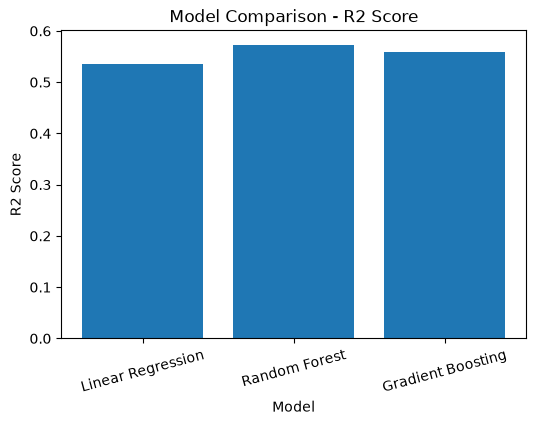

In [76]:
plt.figure(figsize=(6, 4))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)

plt.show()

#### test Random Forest with MinMaxScaler

In [77]:
rf_minmax_model = Pipeline([
    ("preprocessor", preprocessor_minmax),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_minmax_model.fit(X_train, y_train)

rf_minmax_predictions = rf_minmax_model.predict(X_test)

In [78]:
rf_minmax_mae = mean_absolute_error(
    y_test,
    rf_minmax_predictions
)

rf_minmax_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_minmax_predictions
    )
)

rf_minmax_r2 = r2_score(
    y_test,
    rf_minmax_predictions
)

print("Random Forest + MinMaxScaler")
print("MAE:", rf_minmax_mae)
print("RMSE:", rf_minmax_rmse)
print("R2 Score:", rf_minmax_r2)

Random Forest + MinMaxScaler
MAE: 31.63484990380776
RMSE: 43.958144955192076
R2 Score: 0.5732598482290638


In [79]:
results = pd.concat([
    results,
    pd.DataFrame({
        "Model": ["Random Forest + MinMaxScaler"],
        "MAE": [rf_minmax_mae],
        "RMSE": [rf_minmax_rmse],
        "R2 Score": [rf_minmax_r2]
    })
], ignore_index=True)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,33.691866,45.879605,0.535138
1,Random Forest,31.661252,44.002564,0.572397
2,Gradient Boosting,32.543657,44.648289,0.559755
3,Random Forest + MinMaxScaler,31.634850,43.958145,0.573260


#### Check Overfitting

In [80]:
rf_train_predictions = random_forest_model.predict(X_train)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

rf_test_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Training R2:", rf_train_r2)
print("Random Forest Testing R2:", rf_test_r2)

Random Forest Training R2: 0.940580049386669
Random Forest Testing R2: 0.5723969836295497


In [81]:
from sklearn.model_selection import RandomizedSearchCV
parameter_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [82]:
tuning = RandomizedSearchCV(
    random_forest_model,
    param_distributions=parameter_grid,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

tuning.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on th

In [83]:
print("Best Parameters:")
print(tuning.best_params_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 20}


In [84]:
best_model = tuning.best_estimator_

final_predictions = best_model.predict(X_test)

In [85]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("FINAL MODEL RESULTS")
print("-------------------")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

FINAL MODEL RESULTS
-------------------
MAE: 31.37305432869691
RMSE: 43.49270663205446
R2 Score: 0.5822488398567981


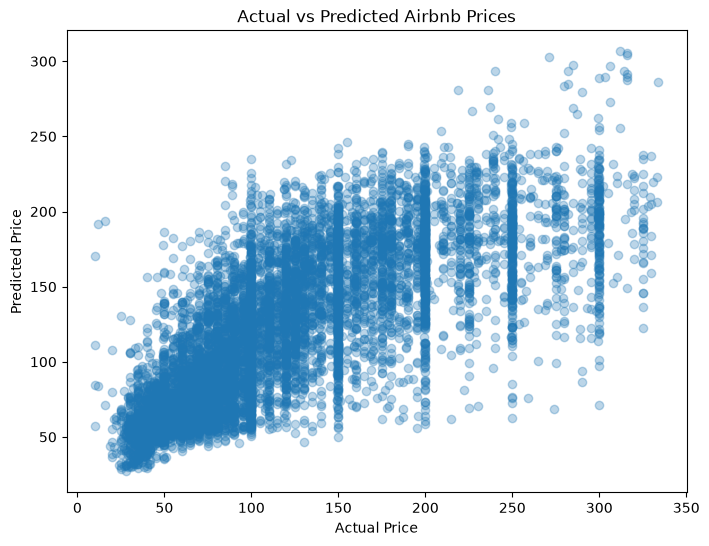

In [86]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

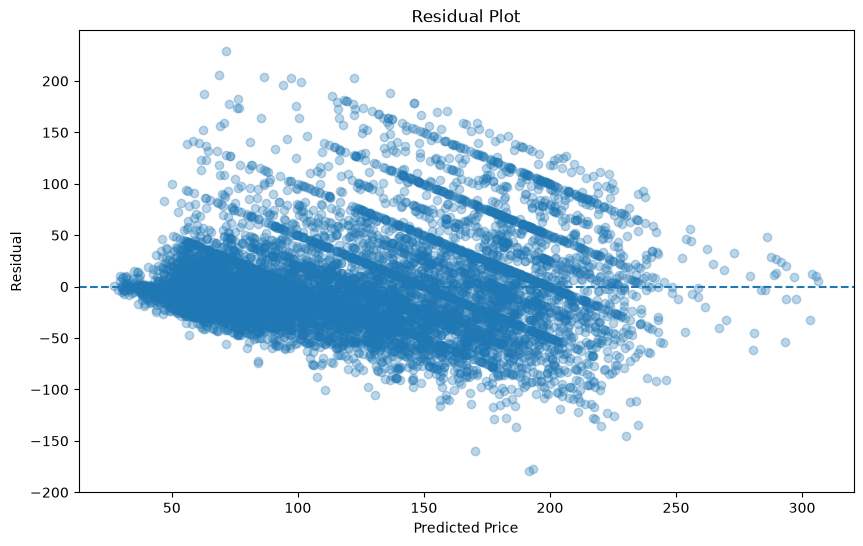

In [87]:
residuals = y_test - final_predictions

plt.figure(figsize=(10, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [88]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_values = best_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
233,cat__room_type_Entire home/apt,0.466062
1,num__longitude,0.149511
0,num__latitude,0.116150
6,num__availability_365,0.048244
9,num__review_availability_ratio,0.040230
8,num__days_since_last_review,0.033333
4,num__reviews_per_month,0.030330
5,num__calculated_host_listings_count,0.025615
2,num__minimum_nights,0.018487
10,num__minimum_nights_log,0.018355


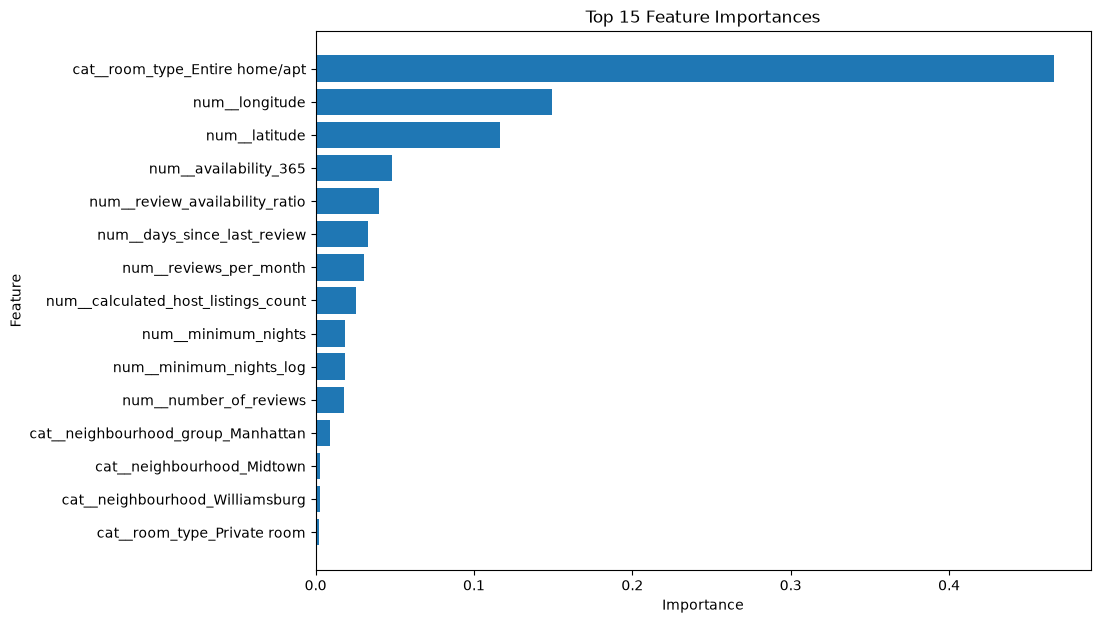

In [89]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [90]:
import joblib

joblib.dump(
    best_model,
    "airbnb_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [91]:
results.to_csv(
    "model_results.csv",
    index=False
)

print("Model results saved.")

Model results saved.


In [92]:
sample_listing = X_test.iloc[[0]]

sample_prediction = best_model.predict(
    sample_listing
)

print("Actual Price:", y_test.iloc[0])
print("Predicted Price:", sample_prediction[0])

Actual Price: 200
Predicted Price: 135.15475609213902


In [93]:
print("Final Model Performance")
print("-----------------------")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

Final Model Performance
-----------------------
MAE: 31.37305432869691
RMSE: 43.49270663205446
R2 Score: 0.5822488398567981


-------------------------